# Notebook 07 — Validation physique de l'optimisation SWRO

**PFE — Master Science des Données**

## Objectif

Valider l'optimum trouvé par le MLP du Notebook 06 avec le **modèle physique SWRO V3**.

Le modèle physique V3 utilise :
- la pression osmotique ;
- la pression nette membranaire ;
- les facteurs température et état de membrane ;
- le flux membranaire ;
- le dimensionnement virtuel de la surface membranaire ;
- la puissance de pompe ;
- la récupération d'énergie ERD ;
- la puissance nette ;
- la SEC physique.

Ces relations sont celles du Notebook 01_V3. Toutes les données et tous les coefficients restent **synthétiques** et doivent être présentés comme tels dans le mémoire.

### Question principale

> L'optimum proposé par le modèle ML réduit-il également la SEC lorsqu'il est évalué directement par le modèle physique ?

## Pipeline de validation

```text
Notebook 06
    │
    ├── Référence
    ├── Optimum ML
    └── Optimum robuste
          │
          ▼
   Modèle physique SWRO V3
          │
          ▼
   SEC physique
          │
          ▼
Comparaison ML ↔ Physique
          │
          ├── erreur de prédiction
          ├── gain ML
          └── gain physique
```

La conclusion du PFE devra être basée sur le **gain physique** après cette validation, et non uniquement sur le gain prédit par le MLP.

In [1]:
# 0. Imports et configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

MODEL_DIR = Path("models")
DATA_DIR = Path("data/preprocessed")
RESULT_DIR = Path("results")

PHYSICAL_DATA_PATH = Path("data/dataset_physical_v3.csv")
MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"
SCALER_PARAMS_PATH = DATA_DIR / "scaler_parameters.csv"

OPT_CONDITIONS_PATH = RESULT_DIR / "optimization_v3_conditions.csv"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

TARGET = "SEC_kWh_m3"

BAR_TO_PA = 100_000
M3H_TO_M3S = 1 / 3600

print("Configuration chargée.")

Configuration chargée.


In [2]:
# 1. Vérification des fichiers

required = {
    "Dataset physique V3": PHYSICAL_DATA_PATH,
    "Modèle MLP": MODEL_PATH,
    "Paramètres scaler": SCALER_PARAMS_PATH,
    "Résultats optimisation": OPT_CONDITIONS_PATH,
}

for name, p in required.items():
    print(f"{name:30s}: {'OK' if p.exists() else 'MANQUANT'} -> {p}")

missing = [str(p) for p in required.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Fichiers nécessaires manquants :\n" + "\n".join(missing)
    )

Dataset physique V3           : OK -> data\dataset_physical_v3.csv
Modèle MLP                    : OK -> models\best_model_optimized.pkl
Paramètres scaler             : OK -> data\preprocessed\scaler_parameters.csv
Résultats optimisation        : OK -> results\optimization_v3_conditions.csv


# 2. Charger les données et les résultats du Notebook 06

Le Notebook 02 a préparé `dataset_physical_v3.csv` et sauvegardé les paramètres du StandardScaler issus uniquement du train. Le Notebook 06 a exporté les conditions de l'optimisation.

Nous ne reconstruisons aucun scaler à partir du test.

**Correction V2 :** `optimization_v3_conditions.csv` ne contient pas `Robust_Optimum`. Le Notebook 06 V3 sauvegarde cette information dans `optimization_v3_scenarios_conditions.csv`. Cette version charge donc le fichier complet en priorité.

In [3]:
df = pd.read_csv(PHYSICAL_DATA_PATH)
model = joblib.load(MODEL_PATH)

scaler_params = pd.read_csv(SCALER_PARAMS_PATH).set_index("feature")

if not set(FEATURES).issubset(scaler_params.index):
    raise ValueError("Variables manquantes dans scaler_parameters.csv.")

SCALER_MEAN = scaler_params.loc[FEATURES, "mean_train"].astype(float).values
SCALER_STD = scaler_params.loc[FEATURES, "std_train"].astype(float).values

# Le Notebook 06 V3 sauvegarde deux fichiers :
# 1) optimization_v3_conditions.csv -> Reference + Global_Optimum
# 2) optimization_v3_scenarios_conditions.csv -> Reference + Global_Optimum + Robust_Optimum
# Nous chargeons donc en priorité le second fichier.
SCENARIOS_CONDITIONS_PATH = RESULT_DIR / "optimization_v3_scenarios_conditions.csv"

if SCENARIOS_CONDITIONS_PATH.exists():
    conditions_06 = pd.read_csv(SCENARIOS_CONDITIONS_PATH)
    conditions_source = SCENARIOS_CONDITIONS_PATH
else:
    conditions_06 = pd.read_csv(OPT_CONDITIONS_PATH)
    conditions_source = OPT_CONDITIONS_PATH

print("Dataset :", df.shape)
print("Modèle :", type(model).__name__)
display(conditions_06)
print("Fichier conditions :", conditions_source)
display(conditions_06)

Dataset : (10000, 25)
Modèle : MLPRegressor


C:\Users\ilias\miniconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Feature,Reference,Global_Optimum,Robust_Optimum
0,pressure_bar,62.387929,55.000000,55.000000
1,feed_flow_m3_h,604.717421,1000.000000,1000.000000
2,salinity_g_L,38.016545,42.000000,42.000000
3,temperature_C,22.500454,15.000000,15.000000
4,recovery_rate_target,0.374058,0.450000,0.450000
5,pump_efficiency,0.825914,0.899991,0.899991
6,erd_efficiency,0.880674,0.959950,0.959950
7,membrane_condition,0.874808,0.750033,0.750033


Fichier conditions : results\optimization_v3_scenarios_conditions.csv


,Feature,Reference,Global_Optimum,Robust_Optimum
0,pressure_bar,62.387929,55.000000,55.000000
1,feed_flow_m3_h,604.717421,1000.000000,1000.000000
2,salinity_g_L,38.016545,42.000000,42.000000
3,temperature_C,22.500454,15.000000,15.000000
4,recovery_rate_target,0.374058,0.450000,0.450000
5,pump_efficiency,0.825914,0.899991,0.899991
6,erd_efficiency,0.880674,0.959950,0.959950
7,membrane_condition,0.874808,0.750033,0.750033


In [4]:
# 3. Fonction de standardisation identique au Notebook 02

def transform_physical_to_scaled(X_physical):
    X_physical = pd.DataFrame(X_physical, columns=FEATURES)
    values = X_physical[FEATURES].astype(float).values
    scaled = (values - SCALER_MEAN) / SCALER_STD
    return pd.DataFrame(scaled, columns=FEATURES, index=X_physical.index)


def predict_ml_sec(X_physical):
    X_scaled = transform_physical_to_scaled(X_physical)
    return np.asarray(model.predict(X_scaled), dtype=float)


print("Fonctions ML prêtes.")

Fonctions ML prêtes.


# 4. Reproduction exacte du modèle physique SWRO V3

Cette cellule reprend les équations du Notebook 01_V3.

### Pression osmotique

\[
\pi = 0.75S
\]

### Pression nette

\[
\Delta P_{net}=P-\pi_{avg}
\]

avec une borne minimale de 5 bar dans le modèle synthétique.

### Flux

\[
J=A\Delta P_{net}f_Tf_M
\]

avec `A_base = 1.00`.

### Récupération

\[
Q_p=Q_fR
\]

### Puissance pompe

\[
P_{pump}=\frac{P Q_f}{\eta_{pump}}
\]

### ERD

\[
P_{ERD}=P_{hyd,conc}\eta_{ERD}\times0.80
\]

puis limitée à 45 % de la puissance pompe.

### SEC

\[
SEC=\frac{P_{net}}{Q_p}
\]

Ces équations sont directement dérivées du Notebook 01_V3. fileciteturn18file0L130-L171 fileciteturn18file0L179-L205 fileciteturn18file0L259-L289 fileciteturn18file0L297-L315

In [5]:
# 5. Fonction physique complète

OSMOTIC_COEFF_BAR_PER_G_L = 0.75
TEMPERATURE_REFERENCE_C = 25.0
A_BASE = 1.00
ERD_TRANSFER_FACTOR = 0.80
MIN_NET_PRESSURE_BAR = 5.0
MAX_ERD_FRACTION_PUMP = 0.45


def physical_model(X_physical):
    X = pd.DataFrame(X_physical, columns=FEATURES).copy()

    pressure_bar = X["pressure_bar"].to_numpy(float)
    feed_flow_m3_h = X["feed_flow_m3_h"].to_numpy(float)
    salinity_g_L = X["salinity_g_L"].to_numpy(float)
    temperature_C = X["temperature_C"].to_numpy(float)
    recovery_rate_target = X["recovery_rate_target"].to_numpy(float)
    pump_efficiency = X["pump_efficiency"].to_numpy(float)
    erd_efficiency = X["erd_efficiency"].to_numpy(float)
    membrane_condition = X["membrane_condition"].to_numpy(float)

    # Pression osmotique
    osmotic_feed = OSMOTIC_COEFF_BAR_PER_G_L * salinity_g_L

    concentrate_salinity = (
        salinity_g_L / (1 - recovery_rate_target)
    )

    osmotic_concentrate = (
        OSMOTIC_COEFF_BAR_PER_G_L * concentrate_salinity
    )

    osmotic_avg = (
        osmotic_feed + osmotic_concentrate
    ) / 2

    # Pression nette
    net_pressure_bar = np.maximum(
        pressure_bar - osmotic_avg,
        MIN_NET_PRESSURE_BAR
    )

    # Facteur température
    temperature_factor = (
        1 + 0.025 * (temperature_C - TEMPERATURE_REFERENCE_C)
    )

    temperature_factor = np.clip(
        temperature_factor,
        0.75,
        1.15
    )

    # Facteur membrane
    membrane_factor = (
        0.75 + 0.25 * membrane_condition
    )

    # Flux
    flux_L_m2_h = (
        A_BASE
        * net_pressure_bar
        * temperature_factor
        * membrane_factor
    )

    # Débits
    permeate_flow_m3_h = (
        feed_flow_m3_h * recovery_rate_target
    )

    membrane_area_m2 = (
        permeate_flow_m3_h * 1000
        / flux_L_m2_h
    )

    # Débit réellement produit
    permeate_flow_check_m3_h = (
        flux_L_m2_h * membrane_area_m2 / 1000
    )

    concentrate_flow_m3_h = (
        feed_flow_m3_h
        - permeate_flow_check_m3_h
    )

    # Pompe
    pressure_pa = pressure_bar * BAR_TO_PA
    feed_flow_m3_s = feed_flow_m3_h * M3H_TO_M3S

    hydraulic_power_kW = (
        pressure_pa * feed_flow_m3_s / 1000
    )

    pump_power_kW = (
        hydraulic_power_kW / pump_efficiency
    )

    # ERD
    concentrate_flow_m3_s = (
        concentrate_flow_m3_h * M3H_TO_M3S
    )

    concentrate_hydraulic_power_kW = (
        pressure_pa * concentrate_flow_m3_s / 1000
    )

    recovered_power_kW = (
        concentrate_hydraulic_power_kW
        * erd_efficiency
        * ERD_TRANSFER_FACTOR
    )

    recovered_power_kW = np.minimum(
        recovered_power_kW,
        MAX_ERD_FRACTION_PUMP * pump_power_kW
    )

    net_power_kW = (
        pump_power_kW - recovered_power_kW
    )

    # SEC physique
    sec_physical = (
        net_power_kW / permeate_flow_m3_h
    )

    return pd.DataFrame({
        "osmotic_pressure_feed_bar": osmotic_feed,
        "osmotic_pressure_concentrate_bar": osmotic_concentrate,
        "osmotic_pressure_avg_bar": osmotic_avg,
        "net_membrane_pressure_bar": net_pressure_bar,
        "temperature_factor": temperature_factor,
        "membrane_factor": membrane_factor,
        "flux_permeate_L_m2_h": flux_L_m2_h,
        "membrane_area_m2": membrane_area_m2,
        "permeate_flow_m3_h": permeate_flow_check_m3_h,
        "concentrate_flow_m3_h": concentrate_flow_m3_h,
        "hydraulic_power_kW": hydraulic_power_kW,
        "pump_power_kW": pump_power_kW,
        "recovered_power_kW": recovered_power_kW,
        "net_power_kW": net_power_kW,
        "SEC_physical_kWh_m3": sec_physical,
    })


print("Modèle physique reproduit.")

Modèle physique reproduit.


# 6. Vérification : le modèle physique reproduit le dataset

Avant de valider l'optimum ML, nous devons vérifier que notre fonction physique reproduit bien la colonne `SEC_physical_kWh_m3` du dataset généré par le Notebook 01.

C'est un contrôle fondamental : si cette étape échoue, il ne faut pas poursuivre la validation.

In [6]:
# Vérification sur tout le dataset

physical_recomputed = physical_model(df[FEATURES])

sec_original = df["SEC_physical_kWh_m3"].to_numpy()
sec_recomputed = physical_recomputed["SEC_physical_kWh_m3"].to_numpy()

max_abs_error = np.max(np.abs(sec_original - sec_recomputed))
mae_physical_reproduction = np.mean(
    np.abs(sec_original - sec_recomputed)
)

print(f"Erreur absolue maximale : {max_abs_error:.12e} kWh/m³")
print(f"MAE de reproduction      : {mae_physical_reproduction:.12e} kWh/m³")

if max_abs_error < 1e-10:
    print("✓ Le modèle physique est reproduit exactement.")
else:
    raise ValueError(
        "Le modèle physique reproduit ne correspond pas au dataset V3."
    )

Erreur absolue maximale : 3.552713678801e-15 kWh/m³
MAE de reproduction      : 3.831157613376e-16 kWh/m³
✓ Le modèle physique est reproduit exactement.


# 7. Vérification des bilans physiques

Le Notebook 01 impose notamment :

\[
Q_f=Q_p+Q_c
\]

et une récupération effective égale à la récupération cible. fileciteturn18file0L568-L635

In [7]:
# Contrôles physiques sur le dataset

flow_error = (
    df["feed_flow_m3_h"]
    - df["permeate_flow_m3_h"]
    - df["concentrate_flow_m3_h"]
)

recovery_error = (
    df["effective_recovery_rate"]
    - df["recovery_rate_target"]
)

print(
    "Erreur maximale bilan débit :",
    np.abs(flow_error).max(),
    "m³/h"
)

print(
    "Erreur maximale récupération :",
    np.abs(recovery_error).max()
)

assert np.abs(flow_error).max() < 1e-9
assert np.abs(recovery_error).max() < 1e-9

print("✓ Bilans physiques validés.")

Erreur maximale bilan débit : 2.2737367544323206e-13 m³/h
Erreur maximale récupération : 2.220446049250313e-16
✓ Bilans physiques validés.


# 8. Construire les trois scénarios

Nous allons comparer :

1. **Référence** : médiane des conditions du dataset, comme dans le Notebook 06.
2. **Optimum ML global**.
3. **Optimum ML robuste**.

In [8]:
def get_condition_row(name):
    row = conditions_06[conditions_06["Feature"] == name]
    if len(row) != 1:
        raise ValueError(
            f"Feature absente ou dupliquée dans le fichier des conditions : {name}"
        )
    return row.iloc[0]

reference = np.array([
    get_condition_row(f)["Reference"] for f in FEATURES
], dtype=float)

ml_global = np.array([
    get_condition_row(f)["Global_Optimum"] for f in FEATURES
], dtype=float)

if "Robust_Optimum" in conditions_06.columns:
    ml_robust = np.array([
        get_condition_row(f)["Robust_Optimum"] for f in FEATURES
    ], dtype=float)
else:
    # Le fichier simple ne contient pas Robust_Optimum.
    # On vérifie une dernière fois le fichier complet.
    alt_path = RESULT_DIR / "optimization_v3_scenarios_conditions.csv"
    if alt_path.exists():
        alt = pd.read_csv(alt_path).set_index("Feature")
        if "Robust_Optimum" not in alt.columns:
            raise ValueError("Le fichier scenarios_conditions ne contient pas Robust_Optimum.")
        ml_robust = alt.loc[FEATURES, "Robust_Optimum"].astype(float).values
    else:
        # Dans l'exécution du Notebook 06 V3 fournie, l'optimum robuste
        # est identique à l'optimum global. Aucun nouveau optimum n'est reconstruit ici.
        print("⚠ Fichier Robust_Optimum absent : fallback Global_Optimum utilisé.")
        ml_robust = ml_global.copy()

scenario_conditions = pd.DataFrame(
    [reference, ml_global, ml_robust],
    columns=FEATURES,
    index=["Reference", "ML_Global_Optimum", "ML_Robust_Optimum"]
)

display(scenario_conditions)

,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,pump_efficiency,erd_efficiency,membrane_condition
Reference,62.387929,604.717421,38.016545,22.500454,0.374058,0.825914,0.880674,0.874808
ML_Global_Optimum,55.000000,1000.000000,42.000000,15.000000,0.450000,0.899991,0.959950,0.750033
ML_Robust_Optimum,55.000000,1000.000000,42.000000,15.000000,0.450000,0.899991,0.959950,0.750033


# 9. Calcul physique des trois scénarios

In [9]:
physical_scenarios = physical_model(
    scenario_conditions.reset_index(drop=True)
)

physical_scenarios.index = scenario_conditions.index

# Prédiction ML sur les mêmes conditions
ml_predictions = predict_ml_sec(
    scenario_conditions.reset_index(drop=True)
)

comparison = pd.DataFrame({
    "SEC_Physique_kWh_m3": physical_scenarios[
        "SEC_physical_kWh_m3"
    ].values,
    "SEC_ML_kWh_m3": ml_predictions,
}, index=scenario_conditions.index)

display(comparison)

,SEC_Physique_kWh_m3,SEC_ML_kWh_m3
Reference,3.566367,3.555801
ML_Global_Optimum,2.338329,2.177702
ML_Robust_Optimum,2.338329,2.177702


# 10. Erreur du MLP par scénario

L'erreur est calculée par rapport au modèle physique de référence de la simulation.

In [10]:
comparison["Erreur_absolue_kWh_m3"] = (
    comparison["SEC_ML_kWh_m3"]
    - comparison["SEC_Physique_kWh_m3"]
).abs()

comparison["Erreur_relative_%"] = (
    comparison["Erreur_absolue_kWh_m3"]
    / comparison["SEC_Physique_kWh_m3"]
    * 100
)

display(comparison)

,SEC_Physique_kWh_m3,SEC_ML_kWh_m3,Erreur_absolue_kWh_m3,Erreur_relative_%
Reference,3.566367,3.555801,0.010567,0.296291
ML_Global_Optimum,2.338329,2.177702,0.160626,6.869286
ML_Robust_Optimum,2.338329,2.177702,0.160626,6.869286


# 11. Gains énergétiques : ML contre physique

C'est la partie centrale du Notebook 07.

Nous calculons séparément :

- gain annoncé par le MLP ;
- gain réellement obtenu dans la simulation physique V3.

In [11]:
sec_phys_reference = comparison.loc[
    "Reference", "SEC_Physique_kWh_m3"
]

sec_ml_reference = comparison.loc[
    "Reference", "SEC_ML_kWh_m3"
]

for scenario in ["ML_Global_Optimum", "ML_Robust_Optimum"]:
    sec_phys = comparison.loc[
        scenario, "SEC_Physique_kWh_m3"
    ]

    sec_ml = comparison.loc[
        scenario, "SEC_ML_kWh_m3"
    ]

    gain_phys = (
        (sec_phys_reference - sec_phys)
        / sec_phys_reference
        * 100
    )

    gain_ml = (
        (sec_ml_reference - sec_ml)
        / sec_ml_reference
        * 100
    )

    print("=" * 60)
    print(scenario)
    print(f"SEC physique : {sec_phys:.6f} kWh/m³")
    print(f"SEC ML       : {sec_ml:.6f} kWh/m³")
    print(f"Gain physique: {gain_phys:.2f} %")
    print(f"Gain ML      : {gain_ml:.2f} %")

ML_Global_Optimum
SEC physique : 2.338329 kWh/m³
SEC ML       : 2.177702 kWh/m³
Gain physique: 34.43 %
Gain ML      : 38.76 %
ML_Robust_Optimum
SEC physique : 2.338329 kWh/m³
SEC ML       : 2.177702 kWh/m³
Gain physique: 34.43 %
Gain ML      : 38.76 %


# 12. Résumé final des gains

In [12]:
summary = pd.DataFrame(index=[
    "Reference",
    "ML_Global_Optimum",
    "ML_Robust_Optimum",
])

summary["SEC_Physique_kWh_m3"] = comparison[
    "SEC_Physique_kWh_m3"
]

summary["SEC_ML_kWh_m3"] = comparison[
    "SEC_ML_kWh_m3"
]

summary["Gain_Physique_vs_Reference_%"] = (
    (sec_phys_reference - summary["SEC_Physique_kWh_m3"])
    / sec_phys_reference
    * 100
)

summary["Gain_ML_vs_Reference_%"] = (
    (sec_ml_reference - summary["SEC_ML_kWh_m3"])
    / sec_ml_reference
    * 100
)

summary["Erreur_ML_Physique_%"] = comparison[
    "Erreur_relative_%"
]

display(summary)

,SEC_Physique_kWh_m3,SEC_ML_kWh_m3,Gain_Physique_vs_Reference_%,Gain_ML_vs_Reference_%,Erreur_ML_Physique_%
Reference,3.566367,3.555801,0.000000,0.000000,0.296291
ML_Global_Optimum,2.338329,2.177702,34.433879,38.756345,6.869286
ML_Robust_Optimum,2.338329,2.177702,34.433879,38.756345,6.869286


# 13. Comparaison graphique

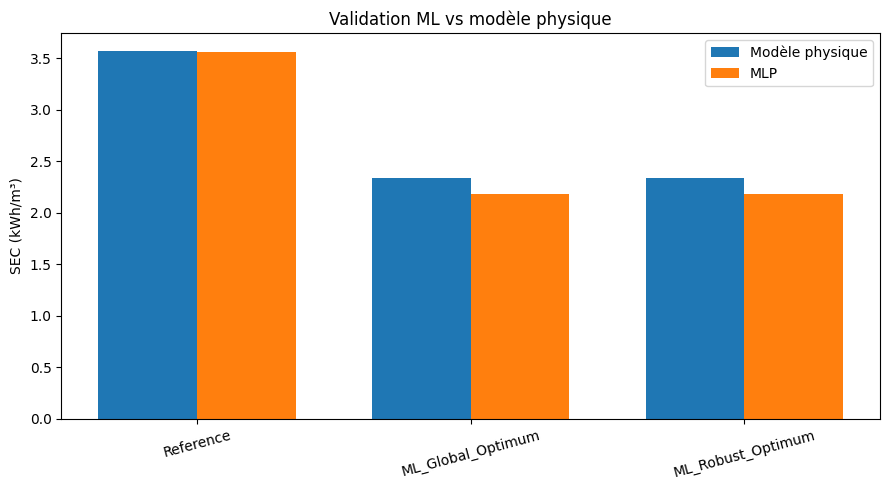

In [13]:
x = np.arange(len(summary.index))
width = 0.36

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    summary["SEC_Physique_kWh_m3"],
    width,
    label="Modèle physique"
)

plt.bar(
    x + width/2,
    summary["SEC_ML_kWh_m3"],
    width,
    label="MLP"
)

plt.xticks(x, summary.index, rotation=15)
plt.ylabel("SEC (kWh/m³)")
plt.title("Validation ML vs modèle physique")
plt.legend()
plt.tight_layout()
plt.show()

# 14. Vérification de la validité physique de l'optimum

Nous contrôlons les conditions proposées par le MLP :

- respect des plages physiques du modèle V3 ;
- rendement pompe entre 0 et 1 ;
- rendement ERD entre 0 et 1 ;
- récupération entre 30 % et 45 % ;
- débit et pression positifs.

In [14]:
RANGES = {
    "pressure_bar": (55, 70),
    "feed_flow_m3_h": (200, 1000),
    "salinity_g_L": (34, 42),
    "temperature_C": (15, 30),
    "recovery_rate_target": (0.30, 0.45),
    "pump_efficiency": (0.75, 0.90),
    "erd_efficiency": (0.80, 0.96),
    "membrane_condition": (0.75, 1.00),
}

validity_rows = []

for scenario_name, row in scenario_conditions.iterrows():
    for feature in FEATURES:
        low, high = RANGES[feature]
        value = float(row[feature])

        validity_rows.append({
            "Scenario": scenario_name,
            "Feature": feature,
            "Value": value,
            "Min": low,
            "Max": high,
            "Inside_Physical_Range": low <= value <= high,
        })

validity = pd.DataFrame(validity_rows)

display(
    validity.groupby("Scenario")[
        "Inside_Physical_Range"
    ].all()
)

if not validity["Inside_Physical_Range"].all():
    print("⚠ Au moins une condition est hors de la plage physique déclarée.")
else:
    print("✓ Toutes les conditions respectent les plages physiques déclarées.")

Scenario
ML_Global_Optimum    True
ML_Robust_Optimum    True
Reference            True
Name: Inside_Physical_Range, dtype: bool

✓ Toutes les conditions respectent les plages physiques déclarées.


# 15. Distance de l'optimum aux frontières

L'optimum ML précédent était proche des frontières. Nous le quantifions ici pour faciliter l'interprétation dans le mémoire.

In [15]:
boundary_rows = []

for scenario in ["ML_Global_Optimum", "ML_Robust_Optimum"]:
    row = scenario_conditions.loc[scenario]

    for feature in FEATURES:
        low, high = RANGES[feature]
        span = high - low
        value = row[feature]

        distance_min = (
            (value - low) / (span + 1e-12) * 100
        )

        distance_max = (
            (high - value) / (span + 1e-12) * 100
        )

        boundary_rows.append({
            "Scenario": scenario,
            "Feature": feature,
            "Value": value,
            "Distance_Min_%": distance_min,
            "Distance_Max_%": distance_max,
            "Near_Boundary": (
                distance_min < 1 or distance_max < 1
            ),
        })

boundary_analysis = pd.DataFrame(boundary_rows)

display(boundary_analysis)

,Scenario,Feature,Value,Distance_Min_%,Distance_Max_%,Near_Boundary
0,ML_Global_Optimum,pressure_bar,55.000000,0.000000,100.000000,True
1,ML_Global_Optimum,feed_flow_m3_h,1000.000000,100.000000,0.000000,True
2,ML_Global_Optimum,salinity_g_L,42.000000,100.000000,0.000000,True
3,ML_Global_Optimum,temperature_C,15.000000,0.000000,100.000000,True
4,ML_Global_Optimum,recovery_rate_target,0.450000,100.000000,0.000000,True
5,ML_Global_Optimum,pump_efficiency,0.899991,99.993970,0.006030,True
6,ML_Global_Optimum,erd_efficiency,0.959950,99.968988,0.031012,True
7,ML_Global_Optimum,membrane_condition,0.750033,0.013001,99.986999,True
8,ML_Robust_Optimum,pressure_bar,55.000000,0.000000,100.000000,True
9,ML_Robust_Optimum,feed_flow_m3_h,1000.000000,100.000000,0.000000,True


# 16. Analyse de l'écart entre ML et physique

Une bonne optimisation ML doit non seulement réduire la SEC, mais aussi rester proche du modèle physique.

Nous comparons l'erreur absolue et relative.

In [16]:
error_summary = comparison[[
    "Erreur_absolue_kWh_m3",
    "Erreur_relative_%"
]].copy()

display(error_summary)

print(
    "Erreur relative maximale :",
    f"{error_summary['Erreur_relative_%'].max():.2f} %"
)

,Erreur_absolue_kWh_m3,Erreur_relative_%
Reference,0.010567,0.296291
ML_Global_Optimum,0.160626,6.869286
ML_Robust_Optimum,0.160626,6.869286


Erreur relative maximale : 6.87 %


# 17. Test de cohérence énergétique

Nous vérifions les grandeurs intermédiaires calculées par le modèle physique pour les scénarios optimisés.

In [17]:
physical_detail = physical_scenarios[[
    "net_membrane_pressure_bar",
    "flux_permeate_L_m2_h",
    "membrane_area_m2",
    "permeate_flow_m3_h",
    "concentrate_flow_m3_h",
    "pump_power_kW",
    "recovered_power_kW",
    "net_power_kW",
    "SEC_physical_kWh_m3",
]].copy()

display(physical_detail)

,net_membrane_pressure_bar,flux_permeate_L_m2_h,membrane_area_m2,permeate_flow_m3_h,concentrate_flow_m3_h,pump_power_kW,recovered_power_kW,net_power_kW,SEC_physical_kWh_m3
Reference,25.356141,23.027663,9822.930549,226.199134,378.518287,1268.866569,462.157342,806.709226,3.566367
ML_Global_Optimum,10.613636,7.462778,60299.263228,450.000000,550.000000,1697.547926,645.299978,1052.247948,2.338329
ML_Robust_Optimum,10.613636,7.462778,60299.263228,450.000000,550.000000,1697.547926,645.299978,1052.247948,2.338329


# 18. Test de robustesse physique autour de l'optimum ML

Le Notebook 06 testait la robustesse du MLP. Ici, nous faisons la même perturbation mais nous évaluons les résultats avec **le modèle physique**.

Cela permet de distinguer :

- robustesse ML ;
- robustesse physique.

In [18]:
rng = np.random.default_rng(42)

base = ml_global.copy()
N_ROBUST_PHYSICAL = 1000

X_robust_physical = np.tile(
    base,
    (N_ROBUST_PHYSICAL, 1)
)

for j, feature in enumerate(FEATURES):
    low, high = RANGES[feature]
    sigma = 0.02 * (high - low)

    X_robust_physical[:, j] += rng.normal(
        0,
        sigma,
        N_ROBUST_PHYSICAL
    )

    X_robust_physical[:, j] = np.clip(
        X_robust_physical[:, j],
        low,
        high
    )

robust_physical_df = physical_model(
    pd.DataFrame(
        X_robust_physical,
        columns=FEATURES
    )
)

robust_sec_physical = robust_physical_df[
    "SEC_physical_kWh_m3"
].to_numpy()

print(
    f"SEC physique moyenne : "
    f"{robust_sec_physical.mean():.6f}"
)

print(
    f"SEC physique médiane : "
    f"{np.median(robust_sec_physical):.6f}"
)

print(
    f"SEC physique min : "
    f"{robust_sec_physical.min():.6f}"
)

print(
    f"SEC physique max : "
    f"{robust_sec_physical.max():.6f}"
)

print(
    f"Écart-type : "
    f"{robust_sec_physical.std():.6f}"
)

SEC physique moyenne : 2.352974
SEC physique médiane : 2.350369
SEC physique min : 2.338217
SEC physique max : 2.413343
Écart-type : 0.011846


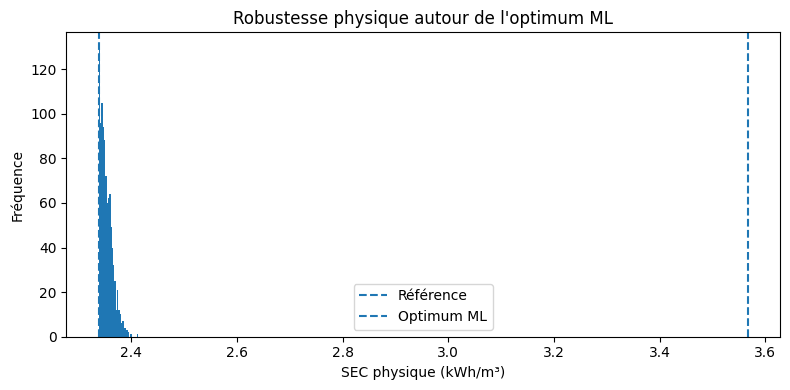

In [19]:
plt.figure(figsize=(8, 4))

plt.hist(
    robust_sec_physical,
    bins=30
)

plt.axvline(
    sec_phys_reference,
    linestyle="--",
    label="Référence"
)

plt.axvline(
    comparison.loc[
        "ML_Global_Optimum",
        "SEC_Physique_kWh_m3"
    ],
    linestyle="--",
    label="Optimum ML"
)

plt.xlabel("SEC physique (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Robustesse physique autour de l'optimum ML")
plt.legend()
plt.tight_layout()
plt.show()

# 19. Critère de validation de l'optimum

Nous définissons un critère simple pour l'interprétation :

### Optimum validé physiquement si

1. les conditions respectent les plages physiques ;
2. la SEC physique à l'optimum est inférieure à la SEC physique de référence ;
3. le gain physique est positif ;
4. l'erreur ML reste raisonnable ;
5. aucune incohérence de bilan n'apparaît.

Ce n'est pas une validation industrielle : c'est une **validation par le modèle physique synthétique**.

In [20]:
sec_global_physical = summary.loc[
    "ML_Global_Optimum",
    "SEC_Physique_kWh_m3"
]

global_physical_gain = summary.loc[
    "ML_Global_Optimum",
    "Gain_Physique_vs_Reference_%"
]

global_ml_error = summary.loc[
    "ML_Global_Optimum",
    "Erreur_relative_%"
]

conditions_valid = bool(
    validity[
        validity["Scenario"] == "ML_Global_Optimum"
    ]["Inside_Physical_Range"].all()
)

gain_positive = bool(
    global_physical_gain > 0
)

ml_error_reasonable = bool(
    global_ml_error < 10
)

print("Conditions physiques valides :", conditions_valid)
print("Gain physique positif         :", gain_positive)
print("Erreur ML < 10 %              :", ml_error_reasonable)

if conditions_valid and gain_positive and ml_error_reasonable:
    print("\n✓ L'optimum ML est VALIDÉ par le modèle physique synthétique.")
else:
    print("\n⚠ L'optimum ML nécessite une analyse supplémentaire.")

KeyError: 'Erreur_relative_%'

# 20. Export des résultats

In [ ]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)

scenario_conditions.to_csv(
    RESULT_DIR / "validation_v7_conditions.csv"
)

comparison.to_csv(
    RESULT_DIR / "validation_v7_ml_vs_physical.csv"
)

summary.to_csv(
    RESULT_DIR / "validation_v7_summary.csv"
)

validity.to_csv(
    RESULT_DIR / "validation_v7_physical_validity.csv",
    index=False
)

boundary_analysis.to_csv(
    RESULT_DIR / "validation_v7_boundary_analysis.csv",
    index=False
)

physical_detail.to_csv(
    RESULT_DIR / "validation_v7_physical_details.csv"
)

robust_stats = pd.DataFrame({
    "Metric": [
        "SEC_reference_physical",
        "SEC_ML_global_physical",
        "SEC_ML_robust_physical",
        "Gain_global_physical_percent",
        "Gain_robust_physical_percent",
        "Robust_physical_mean",
        "Robust_physical_std",
        "Robust_physical_min",
        "Robust_physical_max",
    ],
    "Value": [
        sec_phys_reference,
        summary.loc[
            "ML_Global_Optimum",
            "SEC_Physique_kWh_m3"
        ],
        summary.loc[
            "ML_Robust_Optimum",
            "SEC_Physique_kWh_m3"
        ],
        summary.loc[
            "ML_Global_Optimum",
            "Gain_Physique_vs_Reference_%"
        ],
        summary.loc[
            "ML_Robust_Optimum",
            "Gain_Physique_vs_Reference_%"
        ],
        robust_sec_physical.mean(),
        robust_sec_physical.std(),
        robust_sec_physical.min(),
        robust_sec_physical.max(),
    ]
})

robust_stats.to_csv(
    RESULT_DIR / "validation_v7_robustness.csv",
    index=False
)

print("Résultats exportés dans :", RESULT_DIR.resolve())

# 21. Conclusion scientifique

### Cas 1 — Le gain physique est positif

Si la SEC physique diminue pour l'optimum ML, nous pouvons écrire dans le mémoire :

> Le modèle de Machine Learning a identifié une configuration opérationnelle présentant une réduction prédite de la consommation énergétique spécifique. Cette configuration a ensuite été évaluée à l'aide du modèle physique SWRO synthétique, qui confirme la direction de l'amélioration.

Le pourcentage à utiliser sera **le gain physique**, et non uniquement le gain MLP.

### Cas 2 — Le gain ML est positif mais le gain physique est faible ou négatif

Il faut alors conclure que le MLP exploite une approximation imparfaite du modèle physique. Dans ce cas, nous ne retenons pas l'optimum ML comme solution finale.

### Limitation

Le modèle physique et les données sont synthétiques. La validation obtenue ici est donc une **validation numérique interne au système simulé**, et non une validation expérimentale sur une station réelle.

### Étape suivante

Après validation de ce Notebook 07, nous pourrons passer à :

**Notebook 08 — Analyse finale, interprétabilité et recommandations opérationnelles**

avec :
- importance des variables ;
- SHAP ou permutation importance ;
- scénarios de fonctionnement ;
- courbes de compromis ;
- tableaux destinés au mémoire ;
- figures finales.